In [5]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 

library numpy untuk perhitungan matriks, matplotlib untuk menampilkan gambar , cv2 kalau disini hanya untuk membaca dan menampilkan gambar

Text(0.5, 1.0, 'citra2')

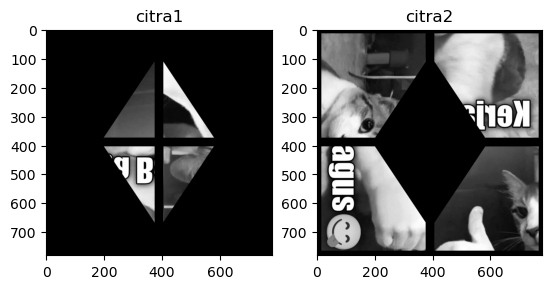

In [38]:
citra1= cv2.imread("assets/citra1.PNG")
citra2= cv2.imread("assets/citra2.PNG")

citra1 = cv2.cvtColor(cv2.imread("assets/citra1.PNG"), cv2.COLOR_BGR2GRAY)
citra2 = cv2.cvtColor(cv2.imread("assets/citra2.PNG"), cv2.COLOR_BGR2GRAY)

plt.subplot(1,2,1)
plt.imshow(citra1, cmap = "gray")
plt.title("citra1")

plt.subplot(1,2,2)
plt.imshow(citra2, cmap ="gray")
plt.title("citra2")

disini menggunakan cv2 untuk membaca dan mengubah citra dalam grayscale dan plt untuk menampilkan citra

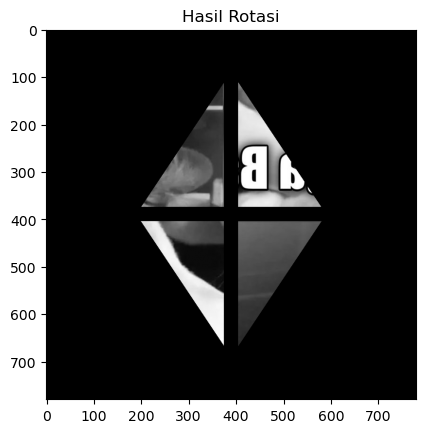

In [39]:
def fungsi_empat_R(img, val):
    h,w = img.shape
    val = int(val) % 360

    if val == 90:
        rot = np.zeros((w,h), dtype=img.dtype)
        for i in range(h):
            for j in range(w):
                rot[j, h-1-i] = img[i,j]
        return rot   
    elif val == 180:
        rot = np.zeros_like(img, dtype=img.dtype)
        for i in range(h):
            for j in range(w):
                rot[h-1-i, w-1-j] = img[i,j]
        return rot
    elif val == 270:
        rot = np.zeros((w,h), dtype=img.dtype)
        for i in range(h):
            for j in range(w):
                rot[w-1-j, i] = img[i,j]
        return rot
    return img

hasil_rotasi = fungsi_empat_R (citra1, 180)

plt.title("Hasil Rotasi")
plt.imshow(hasil_rotasi, cmap='gray')

plt.show()

fungsi di atas adalah rotasi untuk mengubah posisi matriks di citra tersebut sebesar 270 derajat 

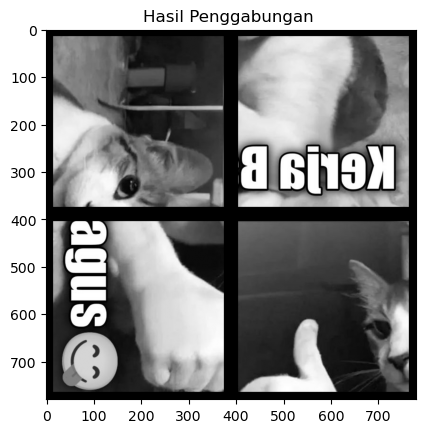

In [24]:
def fungsi_dua_a(citra_1, citra_2):
    return citra_1 + citra_2

hasil_rotasi = fungsi_empat_R(citra1, 180)
hasil_final = fungsi_dua_a(citra2, hasil_rotasi)

plt.title("Hasil Penggabungan ")
plt.imshow(hasil_final, cmap='gray')
plt.show()

pemilihan fungsi penjumlahan untuk citra tersebut untuk menjumlahkan nilai pixel yang ada di citra 1 setelah rotasi dengan citra 2 dengan citra 1 kisaran 100 untuk nilai pixel agar menampilkan citra tanpa ada yang kosong kisaran 100

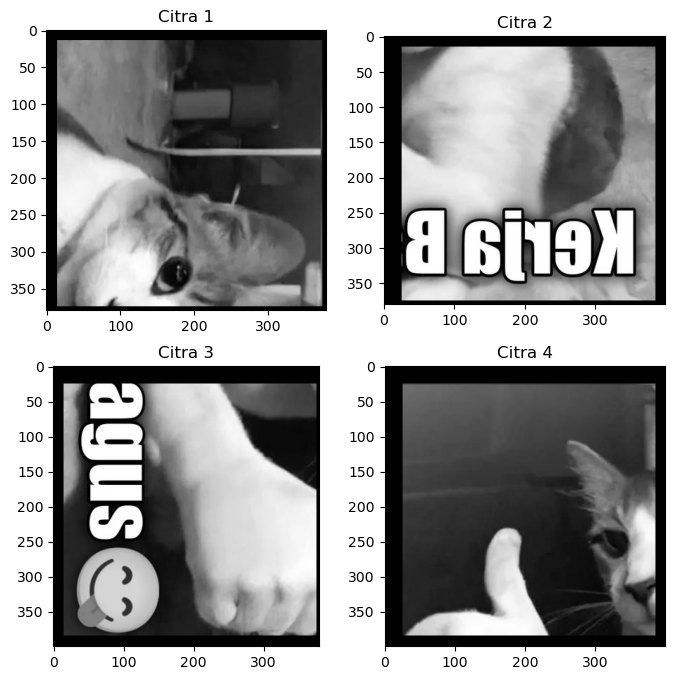

In [25]:
def fungsi_empat_S(gambar, a, b, mode='H'):
 return gambar[a:b, :] if mode == 'H' else gambar[:, a:b]

bagian_atas = fungsi_empat_S(hasil_final, 0, 380, mode='H')
bagian_bawah = fungsi_empat_S(hasil_final, 380, 790, mode='H')

citra_1 = fungsi_empat_S(bagian_atas, 0, 380, mode='V')
citra_2 = fungsi_empat_S(bagian_atas, 380, 790, mode='V')

citra_3 = fungsi_empat_S(bagian_bawah, 0, 380, mode='V')
citra_4 = fungsi_empat_S(bagian_bawah, 380, 790, mode='V') 

plt.figure(figsize=(8, 8))

plt.subplot(2, 2, 1)
plt.title("Citra 1")
plt.imshow(citra_1, cmap='gray')

plt.subplot(2, 2, 2)
plt.title("Citra 2")
plt.imshow(citra_2, cmap='gray')

plt.subplot(2, 2, 3)
plt.title("Citra 3")
plt.imshow(citra_3, cmap='gray')

plt.subplot(2, 2, 4)
plt.title("Citra 4")
plt.imshow(citra_4, cmap='gray')

plt.show()

citra dibagi menjadi 4 kuadran sama besar agar pemrosesan lebih lanjut bisa dilakukan tanpa mengubah nilai pixelnya

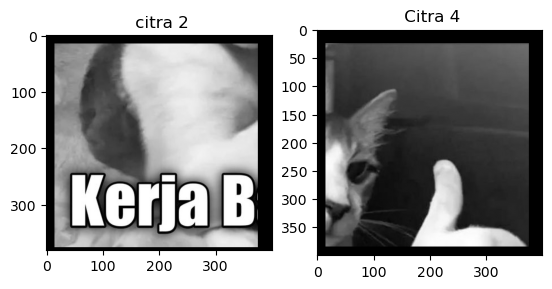

In [26]:
 
def fungsi_satu(image, mode='X'): 
    h, w = image.shape 
    hasil = np.zeros((h, w), dtype=image.dtype) 
    for i in range(h): 
        for j in range(w): 
            if mode == 'X': 
                hasil[i, j] = image[i, w - 1 - j] 
            elif mode == 'Y': 
                hasil[i, j] = image[h - 1 - i, j] 
    return hasil
cermin_2 = fungsi_satu(citra_2, mode='X')
cermin_4 = fungsi_satu(citra_4, mode='X')

plt.subplot(1, 2, 1)
plt.title(" citra 2")
plt.imshow(cermin_2, cmap='gray')

plt.subplot(1, 2, 2)
plt.title(" Citra 4")
plt.imshow(cermin_4, cmap='gray')

plt.show()

disini dilakukan percerminan untuk mendapat citra yang sesuai, disini hanya penempatan nilai pixelnya saja yang diubah yang semula di kanan menjadi kiri.

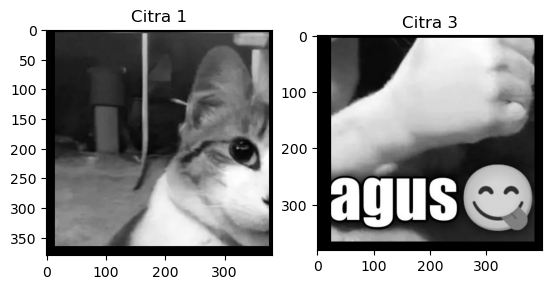

In [27]:
def fungsi_empat_R(image, val): 
    h, w = image.shape 
    val = int(val) % 360  
    if val == 0: return image 
    elif val == 90: 
        rot = np.zeros((w, h), dtype=image.dtype) 
        for i in range(h): 
            for j in range(w): rot[j, h - 1 - i] = image[i, j] 
        return rot 
    elif val == 180: 
        rot = np.zeros_like(image, dtype=image.dtype) 
        for i in range(h): 
            for j in range(w): rot[h - 1 - i, w - 1 - j] = image[i, j] 
        return rot 
    elif val == 270:  
        rot = np.zeros((w, h), dtype=image.dtype) 
        for i in range(h): 
            for j in range(w): rot[w - 1 - j, i] = image[i, j] 
        return rot 
    return image 
 
def fungsi_empat_S(gambar, a, b, mode='H'): 
    return gambar[a:b, :] if mode == 'H' else gambar[:, a:b] 
rotasi_1 = fungsi_empat_R(citra_1, 270)
rotasi_3 = fungsi_empat_R(citra_3, 270)

plt.subplot(1, 2, 1)
plt.title("Citra 1")
plt.imshow(rotasi_1, cmap='gray')

plt.subplot(1, 2, 2)
plt.title("Citra 3")
plt.imshow(rotasi_3, cmap='gray')

plt.show()

kalau disini dilakukan rotasi yang dimana matriksnya di putar searah jarum jam sebesar 270 derajat agar mendapat hasil citra yang diinginkan

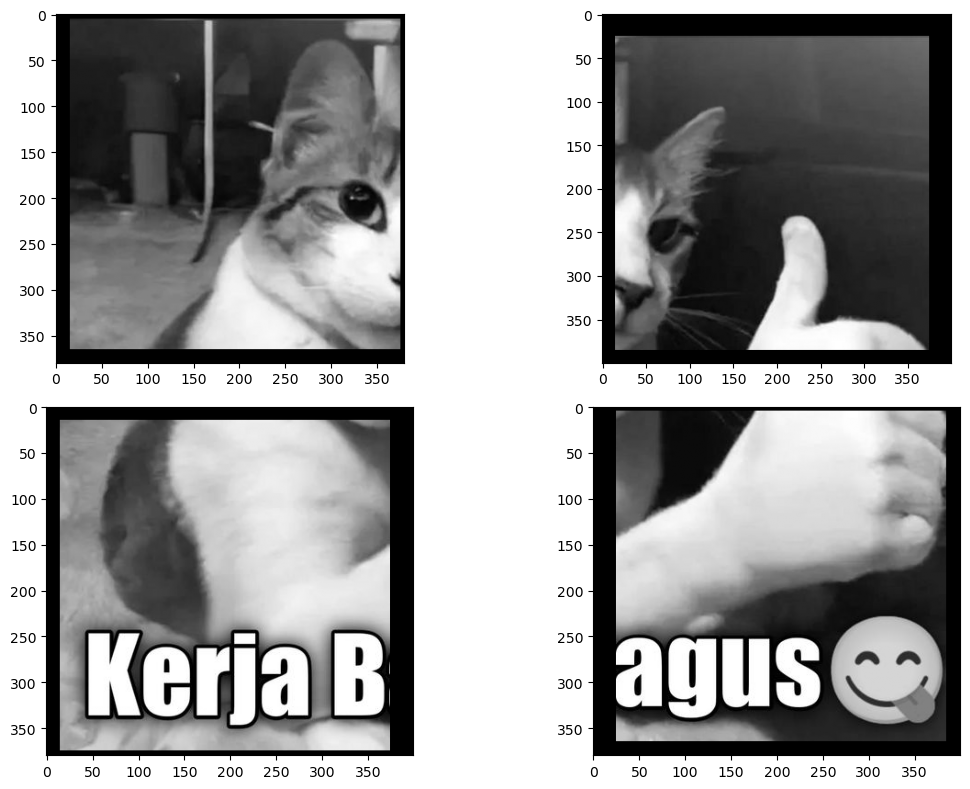

In [32]:
def fungsi_lima(image, geser_kolom_x=0, geser_baris_y=0): 
    image = np.array(image) 
    h, w = image.shape 
    hasil = np.zeros((h, w), dtype=image.dtype) 
    for i in range(h): 
        for j in range(w): 
            new_i = i + geser_baris_y 
            new_j = j + geser_kolom_x 
            if 0 <= new_i < h and 0 <= new_j < w: 
                hasil[new_i, new_j] = image[i, j] 
    return hasil 
cermin_2 = fungsi_satu(citra_2, mode='X')
cermin_4 = fungsi_satu(citra_4, mode='X')

rotasi_1 = fungsi_empat_R(citra_1, 270)
rotasi_3 = fungsi_empat_R(citra_3, 270)

translasi_cermin_2 = fungsi_lima(cermin_2, geser_kolom_x=0, geser_baris_y=0)
translasi_cermin_4 = fungsi_lima(cermin_4, geser_kolom_x=0, geser_baris_y=0)

translasi_rotasi_1 = fungsi_lima(rotasi_1, geser_kolom_x=0, geser_baris_y=0)
translasi_rotasi_3 = fungsi_lima(rotasi_3, geser_kolom_x=0, geser_baris_y=0)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 3)
plt.imshow(translasi_cermin_2, cmap='gray')

plt.subplot(2, 2, 1)
plt.imshow(translasi_rotasi_1, cmap='gray')

plt.subplot(2, 2, 2)
plt.imshow(translasi_cermin_4, cmap='gray')

plt.subplot(2, 2, 4)
plt.imshow(translasi_rotasi_3, cmap='gray')

plt.tight_layout()
plt.show()

translasi disini hanya mengeser posisi matriks dari yang lama ke yang baru tanpa mengubah nilai pixelnya

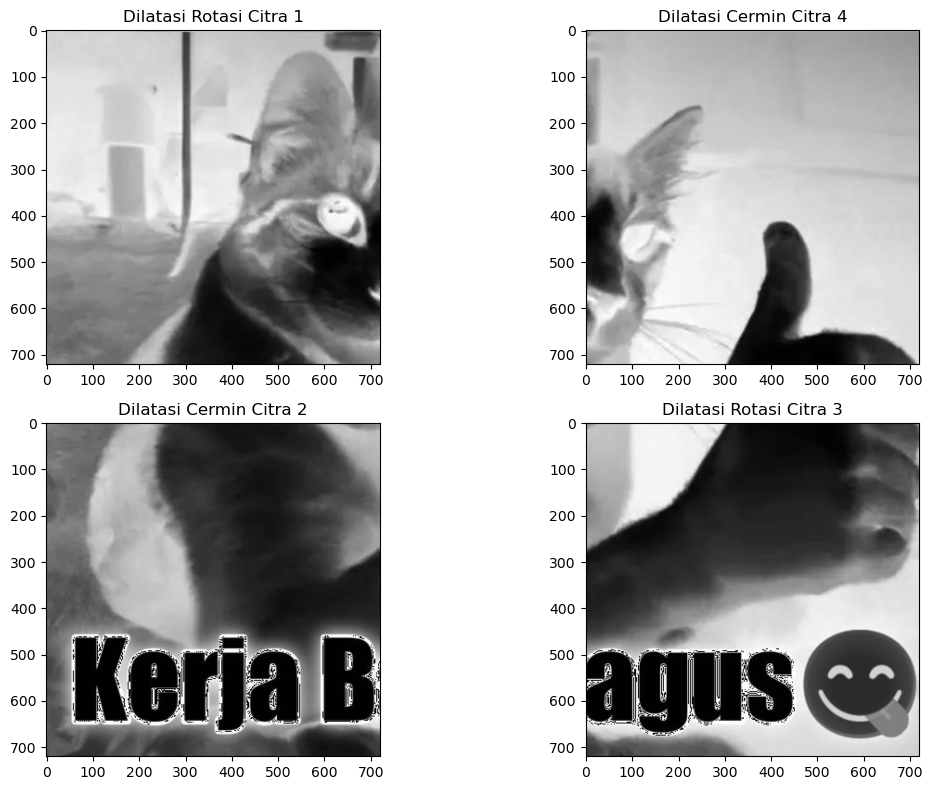

In [44]:
def fungsi_tiga(image, p1=0, p2=0, p3=0, p4=0): 
    h, w = image.shape 
    dilated = np.zeros((h * 2, w * 2)).astype(int) 
    for y in range(h * 2): 
        for x in range(w * 2): 
            dilated[y][x] = image[int(y / 2)][int(x / 2)] 
    sy, ey = max(0, p1), min(h * 2, h * 2 - p2) 
    sx, ex = max(0, p3), min(w * 2, w * 2 - p4) 
    return dilated[sy:ey, sx:ex]

def crop_hitam(image):
    if image.dtype == float:
        image = (image * 255).astype(int)
    
    mask = image > 0
    baris = np.any(mask, axis=1)
    kolom = np.any(mask, axis=0)
    
    if not np.any(baris) or not np.any(kolom):
        return image
    
    y1, y2 = np.where(baris)[0][[0, -1]]
    x1, x2 = np.where(kolom)[0][[0, -1]]
    return image[y1:y2+1, x1:x2+1]

citra_1_int = (citra_1 * 255).astype(int)
citra_2_int = (citra_2 * 255).astype(int)
citra_3_int = (citra_3 * 255).astype(int)
citra_4_int = (citra_4 * 255).astype(int)

cermin_2 = fungsi_satu(citra_2_int, mode='X')
cermin_4 = fungsi_satu(citra_4_int, mode='X')
rotasi_1 = fungsi_empat_R(citra_1_int, 270)
rotasi_3 = fungsi_empat_R(citra_3_int, 270)

translasi_cermin_2 = fungsi_lima(cermin_2, geser_kolom_x=0, geser_baris_y=0)
translasi_cermin_4 = fungsi_lima(cermin_4, geser_kolom_x=0, geser_baris_y=0)
translasi_rotasi_1 = fungsi_lima(rotasi_1, geser_kolom_x=0, geser_baris_y=0)
translasi_rotasi_3 = fungsi_lima(rotasi_3, geser_kolom_x=0, geser_baris_y=0)

geser_x = 0
geser_y = 0
zoom_cermin_2 = fungsi_tiga(translasi_cermin_2, p1=geser_y, p3=geser_x)
zoom_cermin_4 = fungsi_tiga(translasi_cermin_4, p1=geser_y, p3=geser_x)
zoom_rotasi_1 = fungsi_tiga(translasi_rotasi_1, p1=geser_y, p3=geser_x)
zoom_rotasi_3 = fungsi_tiga(translasi_rotasi_3, p1=geser_y, p3=geser_x)

zoom_rotasi_1 = crop_hitam(fungsi_tiga(translasi_rotasi_1))
zoom_cermin_4 = crop_hitam(fungsi_tiga(translasi_cermin_4))
zoom_cermin_2 = crop_hitam(fungsi_tiga(translasi_cermin_2))
zoom_rotasi_3 = crop_hitam(fungsi_tiga(translasi_rotasi_3))

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.title("Dilatasi Rotasi Citra 1" )
plt.imshow(zoom_rotasi_1, cmap = "gray")

plt.subplot(2, 2, 2)
plt.title("Dilatasi Cermin Citra 4")
plt.imshow(zoom_cermin_4, cmap = "gray")

plt.subplot(2, 2, 3)
plt.title("Dilatasi Cermin Citra 2")
plt.imshow(zoom_cermin_2, cmap = "gray")

plt.subplot(2, 2, 4)
plt.title("Dilatasi Rotasi Citra 3")
plt.imshow(zoom_rotasi_3, cmap = "gray")
plt.tight_layout()
plt.show()

dilatasi untuk mempebesar ukuran matriks dari citra tersebut dengan cara menduplikat nilai pexelnya dan ada fungsi crop untuk memetong matriksnya agar  proporsional dan tidak meyisakan grayscale 0

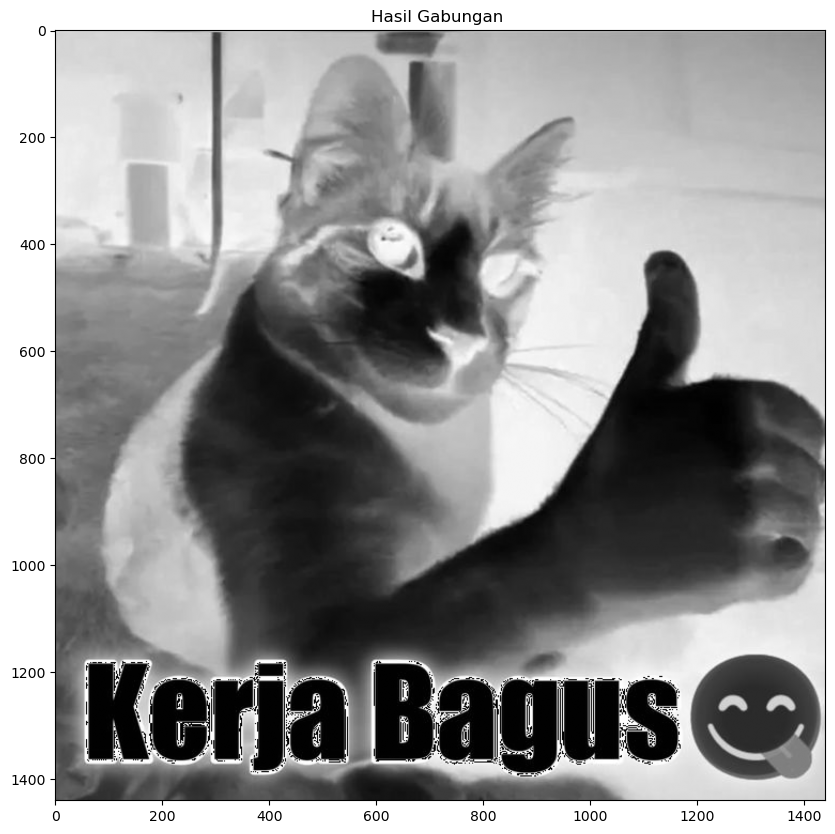

In [35]:
def fungsi_dua_b(citra_1, citra_2): 
    c1, c2 = np.array(citra_1), np.array(citra_2) 
    tinggi = max(c1.shape[0], c2.shape[0]) 
    lebar = c1.shape[1] + c2.shape[1] 
    hasil = np.zeros((tinggi, lebar)).astype(int) 
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1 
    hasil[0:c2.shape[0], c1.shape[1]:] = c2 
    return hasil 
 
def fungsi_dua_c(citra_1, citra_2): 
    c1, c2 = np.array(citra_1), np.array(citra_2) 
    tinggi = c1.shape[0] + c2.shape[0] 
    lebar = max(c1.shape[1], c2.shape[1]) 
    hasil = np.zeros((tinggi, lebar)).astype(int) 
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1 
    hasil[c1.shape[0]:, 0:c2.shape[1]] = c2 
    return hasil 

baris_atas = fungsi_dua_b(zoom_rotasi_1, zoom_cermin_4)

baris_bawah = fungsi_dua_b(zoom_cermin_2, zoom_rotasi_3)

hasil_final = fungsi_dua_c(baris_atas, baris_bawah)

plt.figure(figsize=(10, 10))
plt.title("Hasil Gabungan ")
plt.imshow(hasil_final, cmap='gray')
plt.show()

pengambunagn disini dilakukan secra berbeda yaitu horizontal dengan fungsi b dan vertikal dengan fungsi c yang menghasilkan citra yang utuh yang terdiri dari 4 kuadran.

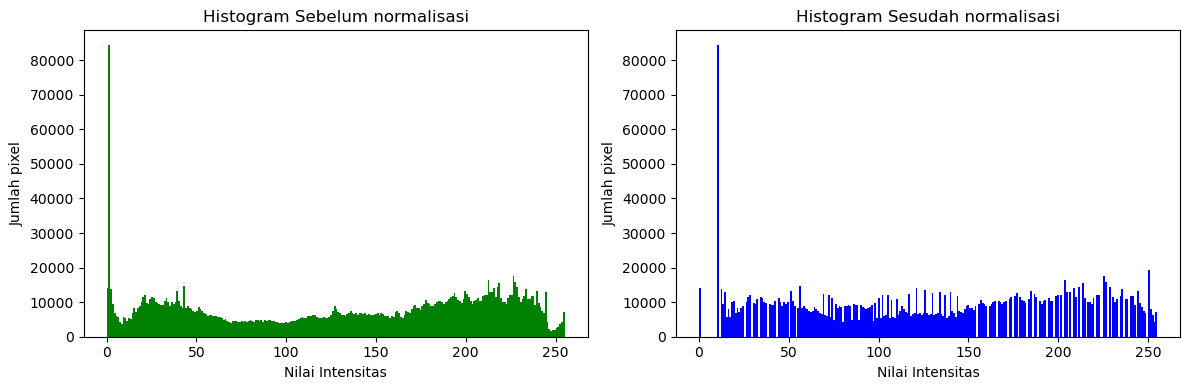

In [36]:
hist, bins = np.histogram(hasil_final.ravel(), bins=256, range=(0, 255))
cdf = hist.cumsum()
cdf_norm = (cdf - cdf.min()) * 255 / (cdf.max() - cdf.min())
hasil_ekualisasi = cdf_norm[hasil_final].astype(int)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.title("Histogram Sebelum normalisasi")
plt.hist(hasil_final.ravel(), bins=256, range=(0, 255), color='green')
plt.xlabel("Nilai Intensitas")
plt.ylabel("Jumlah pixel")

plt.subplot(1, 2, 2)
plt.title("Histogram Sesudah normalisasi")
plt.hist(hasil_ekualisasi.ravel(), bins=256, range=(0, 255), color='blue')
plt.xlabel("Nilai Intensitas")
plt.ylabel("Jumlah pixel")

plt.tight_layout()
plt.show()

Menghitung frekuensi kemunculan setiap nilai piksel (0-255).Cumulative Distribution Function — menjumlahkan frekuensi secara kumulatif dari nilai piksel terkecil ke terbesar.Meregangkan rentang CDF agar distribusi piksel tersebar merata di seluruh rentang 0-255.
Histogram meratakan distribusi intensitas piksel sehingga kontras citra meningkat secara otomatis. Perbedaan histogram sebelum dan sesudah menunjukkan seberapa besar perubahan distribusi piksel yang terjadi — semakin berbeda bentuk histogramnya, semakin signifikan peningkatan kontrasnya.

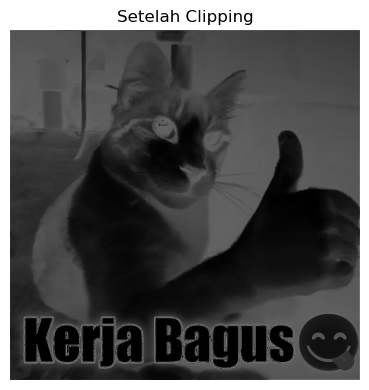

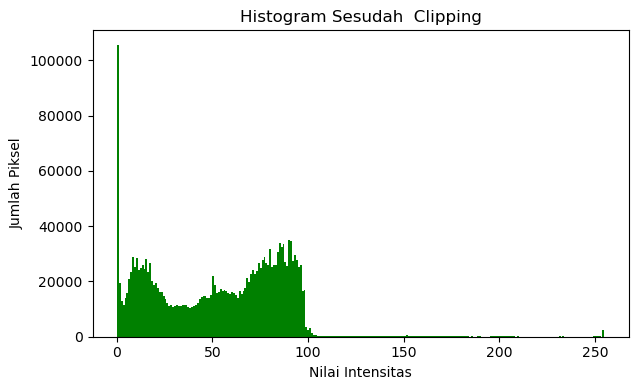

In [41]:
kernel = np.array([
    [-1/10, -1/10, -1/10, -1/10],
    [-1/10,  4/10,  4/10, -1/10],
    [-1/10,  4/10,  4/10, -1/10],
    [-1/10, -1/10, -1/10, -1/10]
])

def zero_padding(image, pad):
    h, w = image.shape
    hasil = np.zeros((h + 2*pad, w + 2*pad))
    hasil[pad:pad+h, pad:pad+w] = image
    return hasil

def konvolusi(image, kernel):
    k = kernel.shape[0]
    pad = k // 2
    padded = zero_padding(image, pad)
    h, w = image.shape
    hasil = np.zeros((h, w))
    for i in range(h):
        for j in range(w):
            hasil[i, j] = np.sum(padded[i:i+k, j:j+k] * kernel)
    return hasil

def clipping(image):
    return np.clip(image, 0, 255).astype(int)

hasil_padding  = zero_padding(hasil_final, pad=2)
hasil_konv     = konvolusi(hasil_final, kernel)
hasil_clipping = clipping(hasil_konv)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.title("Setelah Clipping")
plt.imshow(hasil_clipping, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 2)
plt.title("Histogram Sesudah  Clipping")
plt.hist(hasil_clipping.ravel(), bins=256, range=(0, 255), color='green')
plt.xlabel("Nilai Intensitas")
plt.ylabel("Jumlah Piksel")

plt.tight_layout()
plt.show()

Menambahkan border nol di sekeliling citra sebesar pad = k//2 = 2 piksel dengan tujuan memastikan piksel di tepi citra tetap bisa dikenai konvolusi penuh dan menjaga ukuran output sama dengan ukuran input setelah konvolusi. Kernel ini berfungsi sebagai edge sharpening, bagian tengah bernilai positif (4/10) memperkuat piksel pusat, bagian tepi bernilai negatif (-1/10) mengurangi piksel sekitarnya. Efeknya tepi dan detail gambar menjadi lebih tajam, namun nilai piksel bisa keluar dari rentang 0-255. clipping bertujuan memotong nilai piksel yang negatif menjadi 0, memotong nilai piksel yang melebihi 255 menjadi 255, dan memastikan citra tetap valid dan bisa ditampilkan. Histogram sesudah clipping menunjukkan penumpukan piksel di nilai 0 dan 255, yang mengindikasikan peningkatan kontras dan ketajaman tepi pada citra hasil akhir.